# Single-Sample Forward Prediction and Inversion

This notebook loads the exported fixed sample, runs the same trained imaging model, and optionally runs the same DDPM-enhanced inversion loop from `paper_verison.ipynb`. It does not include any model training code.

In [ ]:
"""Run forward prediction and inversion for the exported fixed sample."""
from __future__ import annotations

import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import scipy.ndimage
import torch
from matplotlib import font_manager
from matplotlib.colors import ListedColormap


BASE_DIR = Path("new_code_simple_data")#your path to the code and data
PACKAGE_DIR = BASE_DIR / "final" / "ddpm_clean_package"
TEST_DATA_DIR = BASE_DIR / "test_data"
OUTPUT_DIR = BASE_DIR / "single_sample_results"

FONT_PATH = Path("Times_New_Roman.ttf")
VELOCITY_CMAP_FILE = Path("colorbar_ind (1).r@")
IMAGING_CHECKPOINT = Path("checkpoint_simple_true_FUF.pth")
DIFFUSION_CODE_DIR = Path("diffefwi")
DIFFUSION_CHECKPOINT = Path("model/model.pt")

if str(PACKAGE_DIR) not in sys.path:
    sys.path.insert(0, str(PACKAGE_DIR))

from models import FNO_UNet_FNO  # noqa: E402


def setup_plot_style() -> None:
    """Use the same global plotting style as the notebook."""
    if FONT_PATH.exists():
        font_manager.fontManager.addfont(str(FONT_PATH))
    plt.rcParams["font.family"] = "Times New Roman"
    plt.rcParams["font.sans-serif"] = ["Times New Roman"]
    plt.rcParams["mathtext.fontset"] = "stix"
    plt.rcParams["axes.unicode_minus"] = False


def load_velocity_cmap():
    """Load the velocity colormap used by the notebook."""
    if VELOCITY_CMAP_FILE.exists():
        try:
            colors = np.fromfile(VELOCITY_CMAP_FILE, dtype=np.float32).reshape(3, 256).T
            return ListedColormap(colors)
        except Exception:
            pass
    return "turbo"


def load_sample(data_dir: Path) -> dict[str, np.ndarray]:
    """Load the standalone sample exported by export_test_sample.py."""
    names = ("vp", "vs", "smooth_vp", "smooth_vs", "img_PP", "img_PS")
    sample = {name: np.load(data_dir / f"{name}.npy").astype(np.float32, copy=False) for name in names}
    for name, array in sample.items():
        print(f"{name}: {array.shape} {array.dtype}")
    return sample


def normalize_image(image: np.ndarray) -> tuple[np.ndarray, np.float32]:
    """Normalize one image by its absolute maximum, matching MyDataset."""
    scale = np.float32(np.max(np.abs(image)))
    if scale == 0:
        scale = np.float32(1.0)
    return (image / scale).astype(np.float32), scale


def build_imaging_model(device: torch.device) -> torch.nn.Module:
    """Build and load the same FNO-UNet-FNO model used in the notebook."""
    model = FNO_UNet_FNO(
        in_channels=4,
        out_channels=2,
        fno_width=32,
        modes1=16,
        modes2=16,
    ).to(device)
    checkpoint = torch.load(IMAGING_CHECKPOINT, map_location=device)
    model.load_state_dict(checkpoint["model_state_dict"])
    model.eval()
    return model


def denormalize_img(norm_img: torch.Tensor, scale_tensor: torch.Tensor) -> torch.Tensor:
    """Restore PP or PS amplitudes after model prediction."""
    scale = scale_tensor.to(norm_img.device).view(-1, 1, 1, 1)
    return norm_img * scale


def run_forward(model: torch.nn.Module, sample: dict[str, np.ndarray], device: torch.device) -> dict[str, np.ndarray]:
    """Run the trained imaging network for the exported sample."""
    pp_norm, pp_scale = normalize_image(sample["img_PP"])
    ps_norm, ps_scale = normalize_image(sample["img_PS"])

    x = torch.from_numpy(
        np.stack(
            [sample["vp"], sample["vs"], sample["smooth_vp"], sample["smooth_vs"]],
            axis=0,
        )[None]
    ).float().to(device)

    with torch.no_grad():
        outputs = model(x)
        if isinstance(outputs, dict):
            outputs = outputs["out"]

    scales = {
        "pp_scale": torch.tensor([pp_scale], dtype=torch.float32, device=device),
        "ps_scale": torch.tensor([ps_scale], dtype=torch.float32, device=device),
    }
    pred_pp = denormalize_img(outputs[:, 0:1], scales["pp_scale"]).detach().cpu().numpy()
    pred_ps = denormalize_img(outputs[:, 1:2], scales["ps_scale"]).detach().cpu().numpy()

    true_pp = denormalize_img(
        torch.from_numpy(pp_norm[None, None]).float().to(device),
        scales["pp_scale"],
    ).detach().cpu().numpy()
    true_ps = denormalize_img(
        torch.from_numpy(ps_norm[None, None]).float().to(device),
        scales["ps_scale"],
    ).detach().cpu().numpy()

    return {
        "pred": np.concatenate([pred_pp, pred_ps], axis=1),
        "true_PP": true_pp,
        "true_PS": true_ps,
        "label_PP_norm": pp_norm,
        "label_PS_norm": ps_norm,
    }


def save_or_show(fig: plt.Figure, save_path: Path | None, show: bool) -> None:
    """Save figures by default and optionally show them interactively."""
    if save_path is not None:
        save_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, dpi=300, bbox_inches="tight")
        print(f"Saved figure -> {save_path}")
    if show:
        plt.show()
    else:
        plt.close(fig)


def plot_forward_result(
    sample: dict[str, np.ndarray],
    forward: dict[str, np.ndarray],
    cmap_vel,
    save_path: Path | None,
    show: bool,
) -> None:
    """Reproduce the notebook forward-prediction figure for target_idx=8."""
    pred = forward["pred"]
    true_pp = forward["true_PP"]
    true_ps = forward["true_PS"]

    fig, axes = plt.subplots(5, 2, figsize=(10.8, 7.75))

    img1 = axes[0, 0].imshow(sample["vp"], cmap=cmap_vel)
    axes[0, 0].set_title("(a) True Vp", pad=-3, y=-0.15)
    axes[0, 0].xaxis.set_label_position("top")
    axes[0, 0].xaxis.tick_top()
    plt.colorbar(img1, ax=axes[0, 0], label="m/s")

    img2 = axes[1, 0].imshow(sample["smooth_vp"], cmap=cmap_vel)
    axes[1, 0].set_title("(c) Initial Vp", pad=-3, y=-0.15)
    axes[1, 0].xaxis.set_label_position("top")
    axes[1, 0].xaxis.tick_top()
    plt.colorbar(img2, ax=axes[1, 0], label="m/s")

    vm_pp = np.percentile(true_pp[0, 0], 98)
    img3 = axes[2, 0].imshow(true_pp[0, 0], cmap="gray", vmin=-vm_pp, vmax=vm_pp)
    axes[2, 0].set_title("(e) PP image by ERTM", pad=-3, y=-0.15)
    axes[2, 0].xaxis.set_label_position("top")
    axes[2, 0].xaxis.tick_top()
    plt.colorbar(img3, ax=axes[2, 0])

    img4 = axes[3, 0].imshow(pred[0, 0], cmap="gray", vmin=-vm_pp, vmax=vm_pp)
    axes[3, 0].set_title("(g) Predicted PP image", pad=-3, y=-0.15)
    axes[3, 0].xaxis.set_label_position("top")
    axes[3, 0].xaxis.tick_top()
    plt.colorbar(img4, ax=axes[3, 0], label=" ")

    img5 = axes[0, 1].imshow(sample["vs"], cmap=cmap_vel)
    axes[0, 1].set_title("(b) True Vs", pad=-3, y=-0.15)
    axes[0, 1].xaxis.set_label_position("top")
    axes[0, 1].xaxis.tick_top()
    plt.colorbar(img5, ax=axes[0, 1], label="m/s")

    img6 = axes[1, 1].imshow(sample["smooth_vs"], cmap=cmap_vel)
    axes[1, 1].set_title("(d) Initial Vs", pad=-3, y=-0.15)
    axes[1, 1].xaxis.set_label_position("top")
    axes[1, 1].xaxis.tick_top()
    plt.colorbar(img6, ax=axes[1, 1], label="m/s")

    vm_ps = np.percentile(pred[0, 1], 98)
    img7 = axes[2, 1].imshow(true_ps[0, 0], cmap="gray", vmin=-vm_ps, vmax=vm_ps)
    axes[2, 1].set_title("(f) PS image by ERTM", pad=-3, y=-0.15)
    axes[2, 1].xaxis.set_label_position("top")
    axes[2, 1].xaxis.tick_top()
    plt.colorbar(img7, ax=axes[2, 1])

    img8 = axes[3, 1].imshow(pred[0, 1], cmap="gray", vmin=-vm_ps, vmax=vm_ps)
    axes[3, 1].set_title("(h) Predicted PS image", pad=-3, y=-0.15)
    axes[3, 1].xaxis.set_label_position("top")
    axes[3, 1].xaxis.tick_top()
    plt.colorbar(img8, ax=axes[3, 1])

    diff_pp = np.abs(pred[0, 0] - true_pp[0, 0])
    img9 = axes[4, 0].imshow(diff_pp, cmap="gray", vmin=-vm_pp, vmax=vm_pp)
    axes[4, 0].set_title("(i) PP residual", pad=-3, y=-0.15)
    axes[4, 0].xaxis.set_label_position("top")
    axes[4, 0].xaxis.tick_top()
    plt.colorbar(img9, ax=axes[4, 0])

    diff_ps = np.abs(pred[0, 1] - true_ps[0, 0])
    img10 = axes[4, 1].imshow(diff_ps, cmap="gray", vmin=-vm_ps, vmax=vm_ps)
    axes[4, 1].set_title("(j) PS residual", pad=-3, y=-0.15)
    axes[4, 1].xaxis.set_label_position("top")
    axes[4, 1].xaxis.tick_top()
    plt.colorbar(img10, ax=axes[4, 1])

    plt.tight_layout()
    save_or_show(fig, save_path, show)


def normalize_velocity_per(v: torch.Tensor, vmin: torch.Tensor, vmax: torch.Tensor, eps: float | None = None) -> torch.Tensor:
    """Normalize one velocity model to [-1, 1] using per-sample limits."""
    if eps is None:
        eps = torch.finfo(v.dtype).eps
    return (v - vmin) / (vmax - vmin + eps) * 2.0 - 1.0


def denormalize_velocity_per(v: torch.Tensor, vmin: torch.Tensor, vmax: torch.Tensor) -> torch.Tensor:
    """Denormalize one velocity model from [-1, 1] to physical units."""
    return (v + 1.0) / 2.0 * (vmax - vmin) + vmin


def load_diffusion_model(device: torch.device):
    """Load the same DDPM prior used by the notebook."""
    if str(DIFFUSION_CODE_DIR) not in sys.path:
        sys.path.append(str(DIFFUSION_CODE_DIR))
    from diffefwi.diffusion_lina import DenoisingDiffusionProbabilisticModel, UNetModel

    ddpm = DenoisingDiffusionProbabilisticModel(timesteps=1000)
    model_diff = UNetModel(
        in_channels=2,
        model_channels=128,
        out_channels=2,
        channel_mult=(1, 2, 4, 8),
        num_res_blocks=2,
    ).to(device)
    model_diff.load_state_dict(torch.load(DIFFUSION_CHECKPOINT, map_location=device))
    model_diff.eval()
    return ddpm, model_diff


def run_inversion(
    model: torch.nn.Module,
    sample: dict[str, np.ndarray],
    forward: dict[str, np.ndarray],
    device: torch.device,
    num_steps: int,
    use_ddpm: bool,
) -> dict[str, np.ndarray | list[float]]:
    """Run the notebook inversion loop for the exported sample."""
    for p in model.parameters():
        p.requires_grad = False

    vp_smooth = torch.from_numpy(sample["smooth_vp"][None]).float().to(device)
    vs_smooth = torch.from_numpy(sample["smooth_vs"][None]).float().to(device)
    label_pp = torch.from_numpy(forward["label_PP_norm"][None]).float().to(device)
    label_ps = torch.from_numpy(forward["label_PS_norm"][None]).float().to(device)

    vp_init = torch.nn.Parameter(vp_smooth.clone())
    vs_init = torch.nn.Parameter(vs_smooth.clone())
    optim_v = torch.optim.Adam([vp_init, vs_init], lr=5)
    loss_fn = torch.nn.MSELoss()

    ddpm = None
    model_diff = None
    if use_ddpm:
        ddpm, model_diff = load_diffusion_model(device)

    loss_list = []
    vp_init0 = vp_init.detach().cpu().numpy().copy()
    vs_init0 = vs_init.detach().cpu().numpy().copy()
    vp_before_ddpm = None
    vs_before_ddpm = None
    vp_after_ddpm = None
    vs_after_ddpm = None

    for step in range(num_steps):
        x = torch.stack([vp_init, vs_init, vp_smooth, vs_smooth], dim=1).float()
        y = torch.stack([label_pp, label_ps], dim=1).float()

        vmin_p, vmax_p = vp_smooth.min(), vp_smooth.max()
        vmin_s, vmax_s = vs_smooth.min(), vs_smooth.max()

        y_pred = model(x)
        if isinstance(y_pred, dict):
            y_pred = y_pred["out"]

        loss = loss_fn(y_pred, y)
        optim_v.zero_grad()
        loss.backward()

        with torch.no_grad():
            vp_g = vp_init.grad.detach().cpu().numpy()
            vs_g = vs_init.grad.detach().cpu().numpy()
            vp_s = scipy.ndimage.gaussian_filter(vp_g, sigma=0.0)
            vs_s = scipy.ndimage.gaussian_filter(vs_g, sigma=0.0)
            vp_init.grad.copy_(torch.tensor(vp_s, device=device))
            vs_init.grad.copy_(torch.tensor(vs_s, device=device))

        torch.nn.utils.clip_grad_norm_([vp_init, vs_init], max_norm=1.0)
        optim_v.step()

        if use_ddpm and (step % 10 == 0):
            with torch.no_grad():
                vp_before_ddpm = vp_init.detach().cpu().numpy().copy()
                vs_before_ddpm = vs_init.detach().cpu().numpy().copy()
                cur_denorm = torch.stack(
                    [
                        normalize_velocity_per(vp_init.detach(), vmin_p, vmax_p),
                        normalize_velocity_per(vs_init.detach(), vmin_s, vmax_s),
                    ],
                    dim=1,
                )
                sampled = ddpm.fwi_sample_xiao(
                    model_diff,
                    (1, 2, 128, 480),
                    999,
                    cur_denorm,
                )
                vp_next = denormalize_velocity_per(sampled[:, 0], vmin_p, vmax_p).to(device).type_as(vp_init)
                vs_next = denormalize_velocity_per(sampled[:, 1], vmin_s, vmax_s).to(device).type_as(vs_init)
                vp_init.data.copy_(vp_next)
                vs_init.data.copy_(vs_next)
                vp_after_ddpm = vp_init.detach().cpu().numpy().copy()
                vs_after_ddpm = vs_init.detach().cpu().numpy().copy()
            optim_v.zero_grad()

        loss_list.append(loss.item())
        if step % 5 == 0:
            print(f"[{step}] inversion loss = {loss.item():.6f}")

    return {
        "vp_true": sample["vp"],
        "vs_true": sample["vs"],
        "vp_init0": vp_init0,
        "vs_init0": vs_init0,
        "vp_final": vp_init.detach().cpu().numpy().copy(),
        "vs_final": vs_init.detach().cpu().numpy().copy(),
        "vp_before_ddpm": vp_before_ddpm,
        "vs_before_ddpm": vs_before_ddpm,
        "vp_after_ddpm": vp_after_ddpm,
        "vs_after_ddpm": vs_after_ddpm,
        "loss_list": loss_list,
    }


def to_2d(arr: np.ndarray) -> np.ndarray:
    """Convert arrays with singleton dimensions to a 2D image."""
    arr = np.asarray(arr)
    arr = np.squeeze(arr)
    if arr.ndim == 3:
        arr = arr[0]
    return arr


def plot_four(v0, v_true, v_inv, residual, title: str, save_path: Path | None, show: bool) -> None:
    """Reproduce the notebook four-panel inversion plot."""
    v0 = to_2d(v0)
    v_true = to_2d(v_true)
    v_inv = to_2d(v_inv)
    residual = to_2d(residual)
    vmax = np.percentile(v_true, 100)
    vmin = np.percentile(v_true, 0)

    fig = plt.figure(figsize=(17, 6))

    plt.subplot(2, 2, 1)
    plt.title(f"(a) Migration {title}", pad=-15, y=-0.15)
    plt.imshow(v0, cmap="seismic", vmin=vmin, vmax=vmax)
    plt.colorbar()
    ax = plt.gca()
    ax.xaxis.set_ticks_position("top")
    ax.xaxis.set_label_position("top")

    plt.subplot(2, 2, 2)
    plt.title(f"(b) True {title}", pad=-15, y=-0.15)
    plt.imshow(v_true, cmap="seismic")
    plt.colorbar()
    ax = plt.gca()
    ax.xaxis.set_ticks_position("top")
    ax.xaxis.set_label_position("top")

    plt.subplot(2, 2, 3)
    plt.title(f"(c) Inverted {title}", pad=-15, y=-0.15)
    plt.imshow(v_inv, cmap="seismic", vmin=vmin, vmax=vmax)
    plt.colorbar()
    ax = plt.gca()
    ax.xaxis.set_ticks_position("top")
    ax.xaxis.set_label_position("top")

    plt.subplot(2, 2, 4)
    plt.title("(d) Residual", pad=-15, y=-0.15)
    plt.imshow(residual, cmap="seismic")
    plt.colorbar()
    ax = plt.gca()
    ax.xaxis.set_ticks_position("top")
    ax.xaxis.set_label_position("top")

    plt.tight_layout()
    save_or_show(fig, save_path, show)


def plot_loss(loss_list: list[float], save_path: Path | None, show: bool) -> None:
    """Plot the inversion loss curve from the notebook."""
    fig = plt.figure()
    plt.plot(loss_list)
    plt.yscale("log")
    plt.xlabel("Iteration")
    plt.ylabel("Loss")
    plt.title("Inversion without DDPM-enhanced vp & vs")
    save_or_show(fig, save_path, show)


def save_inversion_arrays(result: dict[str, np.ndarray | list[float]], output_dir: Path, use_ddpm: bool) -> None:
    """Save inversion outputs for later plotting or comparison."""
    output_dir.mkdir(parents=True, exist_ok=True)
    np.save(output_dir / "vp_final.npy", np.asarray(result["vp_final"], dtype=np.float32))
    np.save(output_dir / "vs_final.npy", np.asarray(result["vs_final"], dtype=np.float32))
    np.save(output_dir / "loss_list.npy", np.asarray(result["loss_list"], dtype=np.float32))
    if use_ddpm:
        np.save(output_dir / "vp_after_ddpm.npy", np.asarray(result["vp_after_ddpm"], dtype=np.float32))
        np.save(output_dir / "vs_after_ddpm.npy", np.asarray(result["vs_after_ddpm"], dtype=np.float32))
    else:
        np.save(output_dir / "vp_before_ddpm.npy", np.asarray(result["vp_final"], dtype=np.float32))
        np.save(output_dir / "vs_before_ddpm.npy", np.asarray(result["vs_final"], dtype=np.float32))



Using device: cuda
vp: (128, 480) float32
vs: (128, 480) float32
smooth_vp: (128, 480) float32
smooth_vs: (128, 480) float32
img_PP: (128, 480) float32
img_PS: (128, 480) float32
Saved figure -> /ibex/user/renl0b/Lina/new_code_simple_data/single_sample_results/forward_prediction_result.png


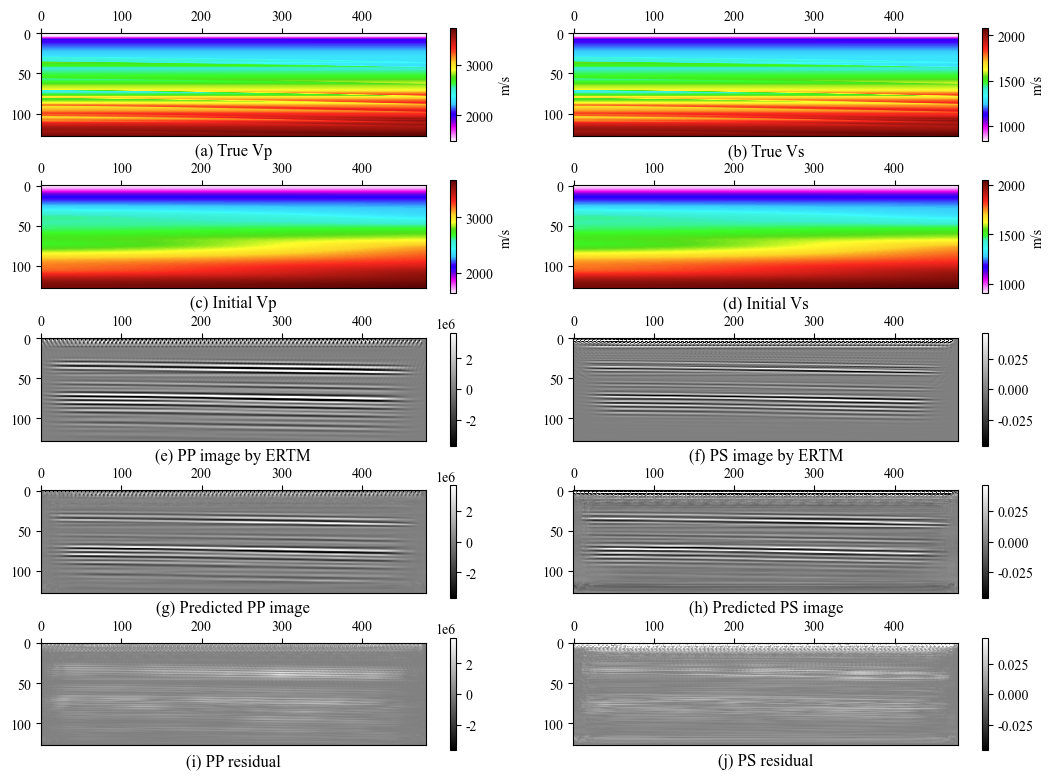

[0] inversion loss = 0.003994
[5] inversion loss = 0.003490
[10] inversion loss = 0.002802
[15] inversion loss = 0.003012
[20] inversion loss = 0.002314
[25] inversion loss = 0.002267
[30] inversion loss = 0.001684
[35] inversion loss = 0.001837
[40] inversion loss = 0.001364
[45] inversion loss = 0.001519
[50] inversion loss = 0.001146
[55] inversion loss = 0.001287
[60] inversion loss = 0.001005
[65] inversion loss = 0.001115
[70] inversion loss = 0.000907
[75] inversion loss = 0.000995
[80] inversion loss = 0.000837
[85] inversion loss = 0.000902
[90] inversion loss = 0.000780
[95] inversion loss = 0.000836
[100] inversion loss = 0.000737
[105] inversion loss = 0.000783
[110] inversion loss = 0.000699
[115] inversion loss = 0.000745
[120] inversion loss = 0.000669
[125] inversion loss = 0.000711
[130] inversion loss = 0.000642
[135] inversion loss = 0.000686
[140] inversion loss = 0.000621
[145] inversion loss = 0.000660
[150] inversion loss = 0.000599
[155] inversion loss = 0.00064

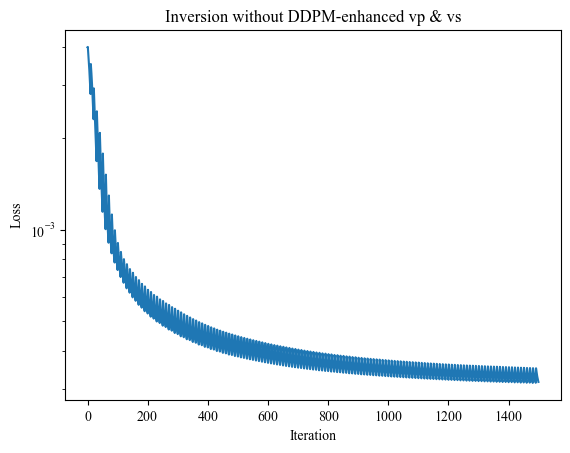

In [ ]:
# Notebook parameters
DATA_DIR = TEST_DATA_DIR
RESULT_DIR = OUTPUT_DIR
NUM_STEPS = 1500
USE_DDPM = True
RUN_NO_DDPM_COMPARISON = True
FORWARD_ONLY = False
SHOW_FIGURES = True

setup_plot_style()
cmap_vel = load_velocity_cmap()
RESULT_DIR.mkdir(parents=True, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.backends.cudnn.benchmark = True
torch.backends.cudnn.enabled = True
print(f"Using device: {device}")

sample = load_sample(DATA_DIR)
model = build_imaging_model(device)

forward = run_forward(model, sample, device)
np.save(RESULT_DIR / "pred_PP.npy", forward["pred"][0, 0].astype(np.float32))
np.save(RESULT_DIR / "pred_PS.npy", forward["pred"][0, 1].astype(np.float32))
plot_forward_result(
    sample,
    forward,
    cmap_vel,
    RESULT_DIR / "forward_prediction_result.png",
    SHOW_FIGURES,
)

result = None
result_with_ddpm = None
result_without_ddpm = None

if not FORWARD_ONLY:
    if USE_DDPM:
        result_with_ddpm = run_inversion(
            model=model,
            sample=sample,
            forward=forward,
            device=device,
            num_steps=NUM_STEPS,
            use_ddpm=True,
        )
        save_inversion_arrays(result_with_ddpm, RESULT_DIR, use_ddpm=True)
        result = result_with_ddpm

        if RUN_NO_DDPM_COMPARISON:
            result_without_ddpm = run_inversion(
                model=model,
                sample=sample,
                forward=forward,
                device=device,
                num_steps=NUM_STEPS,
                use_ddpm=False,
            )
            save_inversion_arrays(result_without_ddpm, RESULT_DIR, use_ddpm=False)
    else:
        result_without_ddpm = run_inversion(
            model=model,
            sample=sample,
            forward=forward,
            device=device,
            num_steps=NUM_STEPS,
            use_ddpm=False,
        )
        save_inversion_arrays(result_without_ddpm, RESULT_DIR, use_ddpm=False)
        result = result_without_ddpm

    active_result = result_with_ddpm if result_with_ddpm is not None else result_without_ddpm
    plot_loss(active_result["loss_list"], RESULT_DIR / "inversion_loss.png", SHOW_FIGURES)



Saved figure -> /ibex/user/renl0b/Lina/new_code_simple_data/single_sample_results/inversion_comparison_four_rows.png


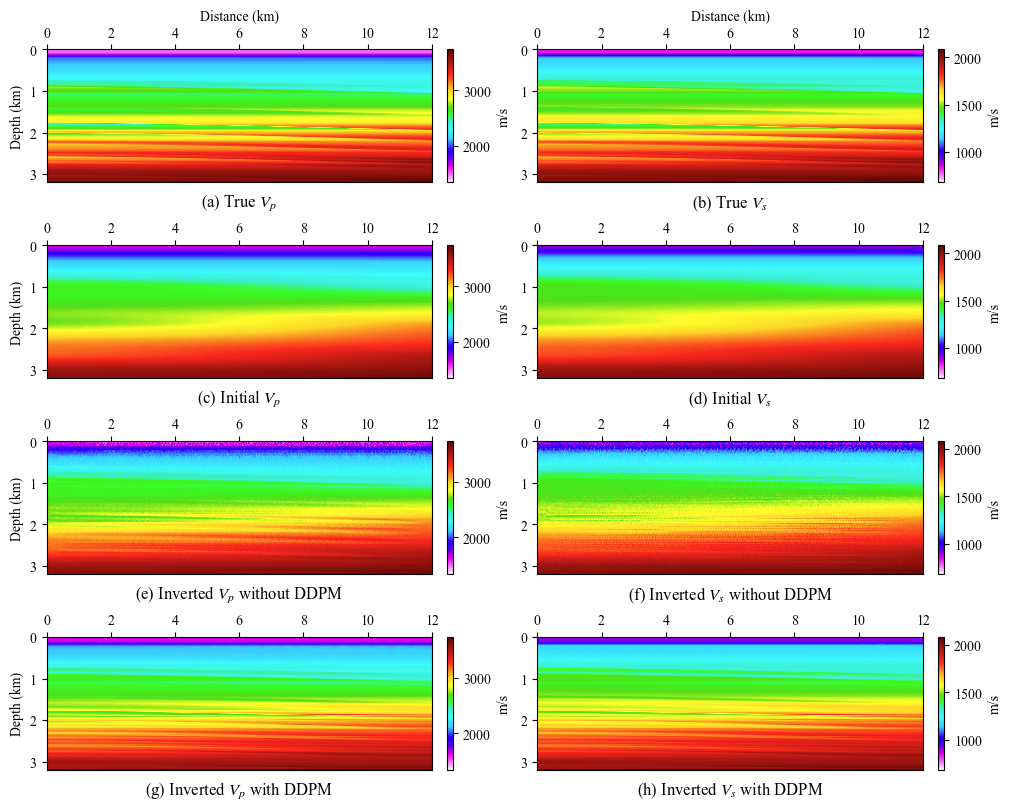

In [5]:
def require_inversion_results(result_with_ddpm, result_without_ddpm):
    """Return both inversion results or raise a clear error for comparison plots."""
    if result_with_ddpm is None or result_without_ddpm is None:
        raise RuntimeError(
            "Comparison plots need both with-DDPM and without-DDPM inversion results. "
            "Set USE_DDPM=True, RUN_NO_DDPM_COMPARISON=True, and FORWARD_ONLY=False, then rerun the main cell."
        )
    return result_with_ddpm, result_without_ddpm


def plot_four_rows(
    vp_true,
    vs_true,
    vp_init,
    vs_init,
    vp_without_ddpm,
    vs_without_ddpm,
    vp_with_ddpm,
    vs_with_ddpm,
    dx=25,
    dz=25,
    cmap=None,
    save_path=None,
    show=True,
):
    """Plot true, initial, no-DDPM inversion, and DDPM inversion in four rows."""
    if cmap is None:
        cmap = cmap_vel

    vp_true = to_2d(vp_true)
    vs_true = to_2d(vs_true)
    vp_init = to_2d(vp_init)
    vs_init = to_2d(vs_init)
    vp_without_ddpm = to_2d(vp_without_ddpm)
    vs_without_ddpm = to_2d(vs_without_ddpm)
    vp_with_ddpm = to_2d(vp_with_ddpm)
    vs_with_ddpm = to_2d(vs_with_ddpm)

    nz, nx = vp_true.shape
    extent = [0, nx * dx / 1000.0, nz * dz / 1000.0, 0]

    vp_vmin = np.percentile(
        np.concatenate([vp_true.ravel(), vp_init.ravel(), vp_without_ddpm.ravel(), vp_with_ddpm.ravel()]),
        0,
    )
    vp_vmax = np.percentile(
        np.concatenate([vp_true.ravel(), vp_init.ravel(), vp_without_ddpm.ravel(), vp_with_ddpm.ravel()]),
        100,
    )
    vs_vmin = np.percentile(
        np.concatenate([vs_true.ravel(), vs_init.ravel(), vs_without_ddpm.ravel(), vs_with_ddpm.ravel()]),
        0,
    )
    vs_vmax = np.percentile(
        np.concatenate([vs_true.ravel(), vs_init.ravel(), vs_without_ddpm.ravel(), vs_with_ddpm.ravel()]),
        100,
    )

    items = [
        (vp_true, vs_true, "(a) True $V_p$", "(b) True $V_s$"),
        (vp_init, vs_init, "(c) Initial $V_p$", "(d) Initial $V_s$"),
        (vp_without_ddpm, vs_without_ddpm, "(e) Inverted $V_p$ without DDPM", "(f) Inverted $V_s$ without DDPM"),
        (vp_with_ddpm, vs_with_ddpm, "(g) Inverted $V_p$ with DDPM", "(h) Inverted $V_s$ with DDPM"),
    ]

    fig, axes = plt.subplots(4, 2, figsize=(10, 8), constrained_layout=True)
    for row, (vp_data, vs_data, vp_title, vs_title) in enumerate(items):
        im_vp = axes[row, 0].imshow(vp_data, cmap=cmap, vmin=vp_vmin, vmax=vp_vmax, extent=extent, aspect="auto")
        axes[row, 0].set_title(vp_title, y=-0.25)
        axes[row, 0].xaxis.set_ticks_position("top")
        axes[row, 0].xaxis.set_label_position("top")
        axes[row, 0].set_ylabel("Depth (km)")
        plt.colorbar(im_vp, ax=axes[row, 0], pad=0.02).set_label("m/s")

        im_vs = axes[row, 1].imshow(vs_data, cmap=cmap, vmin=vs_vmin, vmax=vs_vmax, extent=extent, aspect="auto")
        axes[row, 1].set_title(vs_title, y=-0.25)
        axes[row, 1].xaxis.set_ticks_position("top")
        axes[row, 1].xaxis.set_label_position("top")
        plt.colorbar(im_vs, ax=axes[row, 1], pad=0.02).set_label("m/s")

    axes[0, 0].set_xlabel("Distance (km)")
    axes[0, 1].set_xlabel("Distance (km)")
    save_or_show(fig, Path(save_path) if save_path is not None else None, show)


if not FORWARD_ONLY:
    result_with_ddpm, result_without_ddpm = require_inversion_results(result_with_ddpm, result_without_ddpm)
    plot_four_rows(
        vp_true=result_with_ddpm["vp_true"],
        vs_true=result_with_ddpm["vs_true"],
        vp_init=result_with_ddpm["vp_init0"],
        vs_init=result_with_ddpm["vs_init0"],
        vp_without_ddpm=result_without_ddpm["vp_final"],
        vs_without_ddpm=result_without_ddpm["vs_final"],
        vp_with_ddpm=result_with_ddpm["vp_after_ddpm"],
        vs_with_ddpm=result_with_ddpm["vs_after_ddpm"],
        dx=25,
        dz=25,
        cmap=cmap_vel,
        save_path=RESULT_DIR / "inversion_comparison_four_rows.png",
        show=SHOW_FIGURES,
    )


Saved figure -> /ibex/user/renl0b/Lina/new_code_simple_data/single_sample_results/trace_200_vp_comparison.png


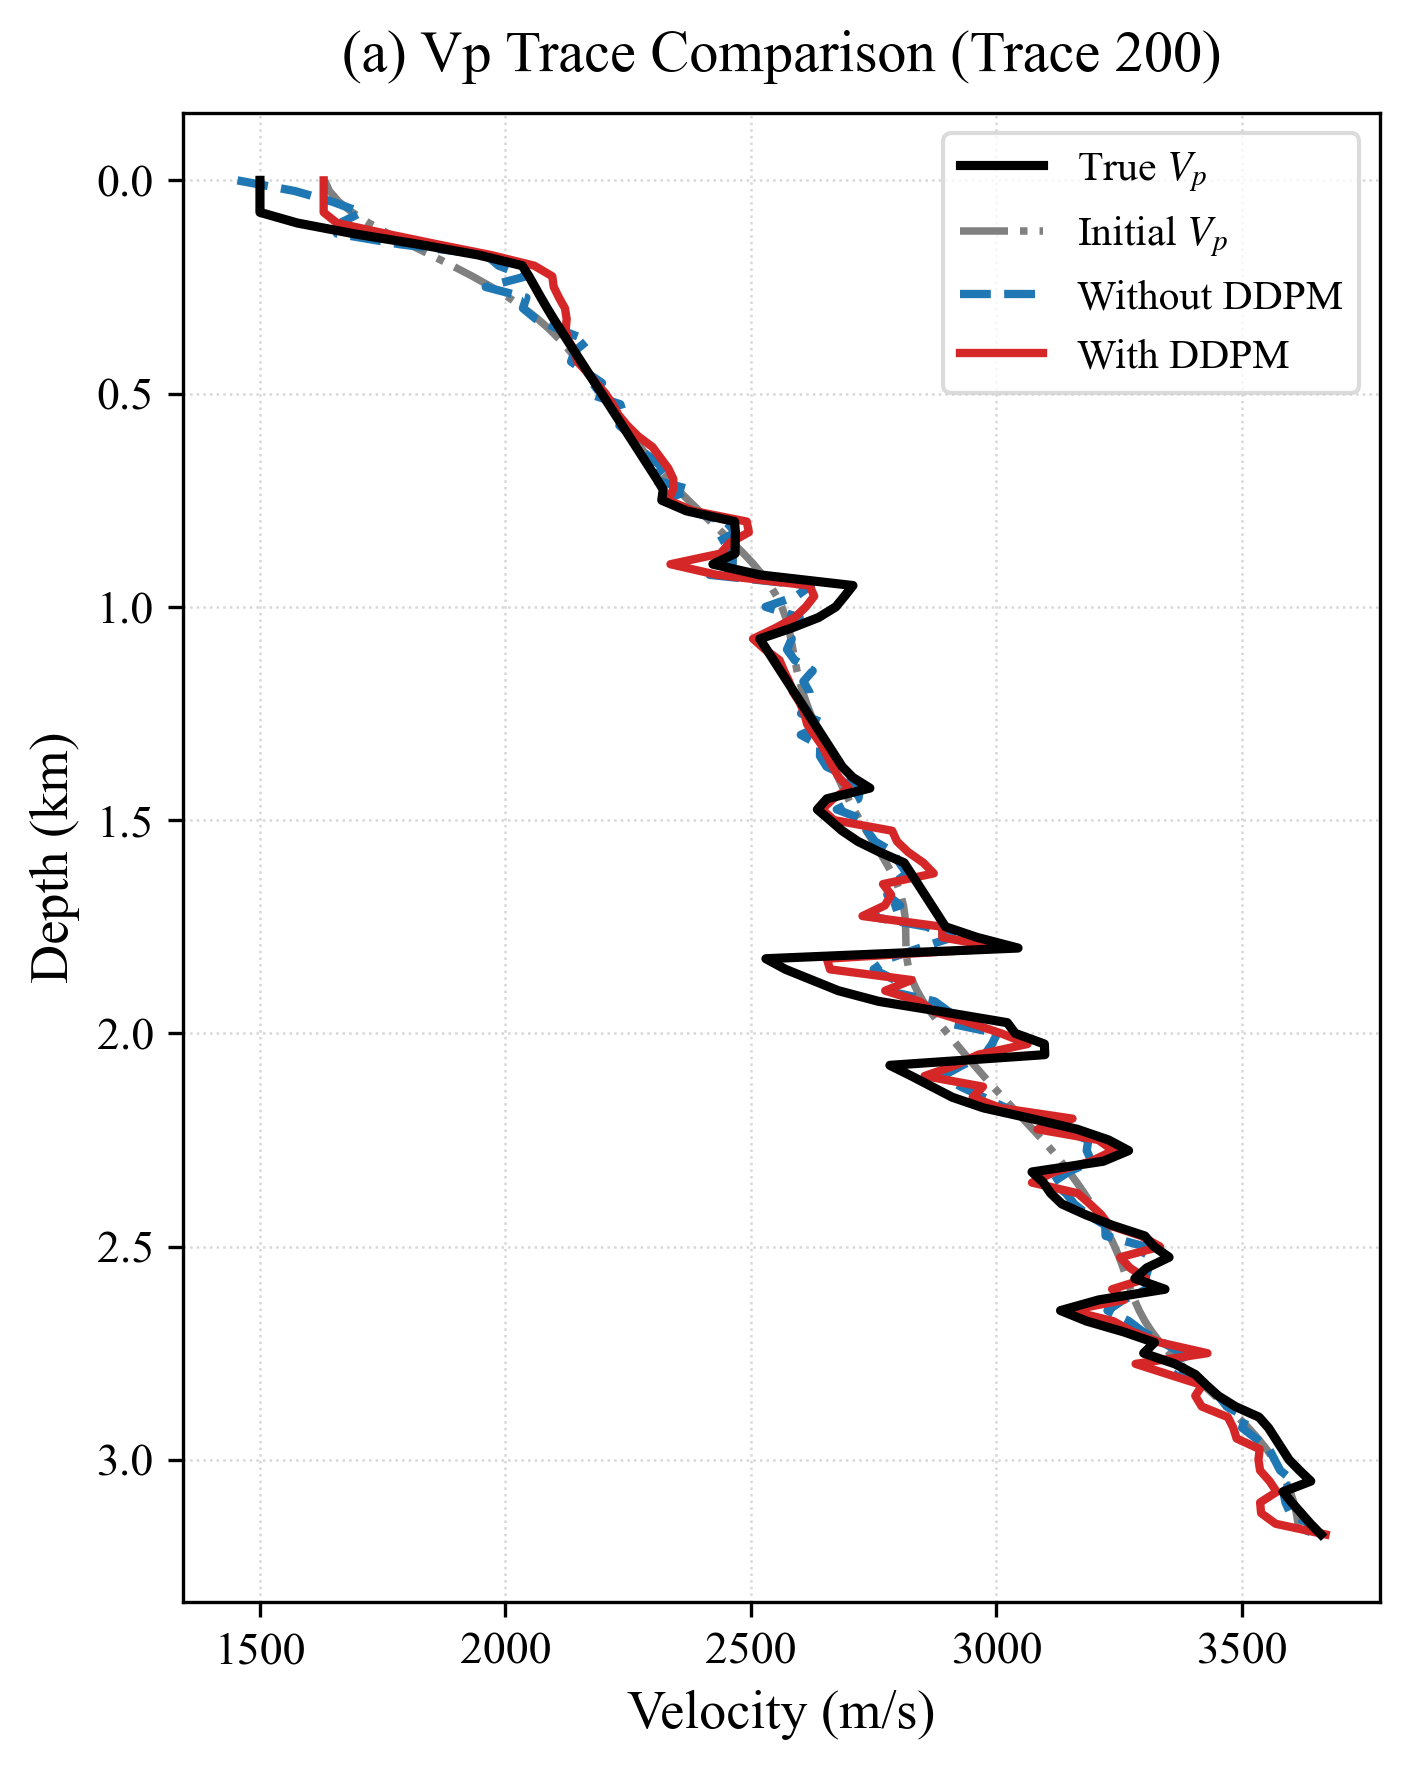

Saved figure -> /ibex/user/renl0b/Lina/new_code_simple_data/single_sample_results/trace_200_vs_comparison.png


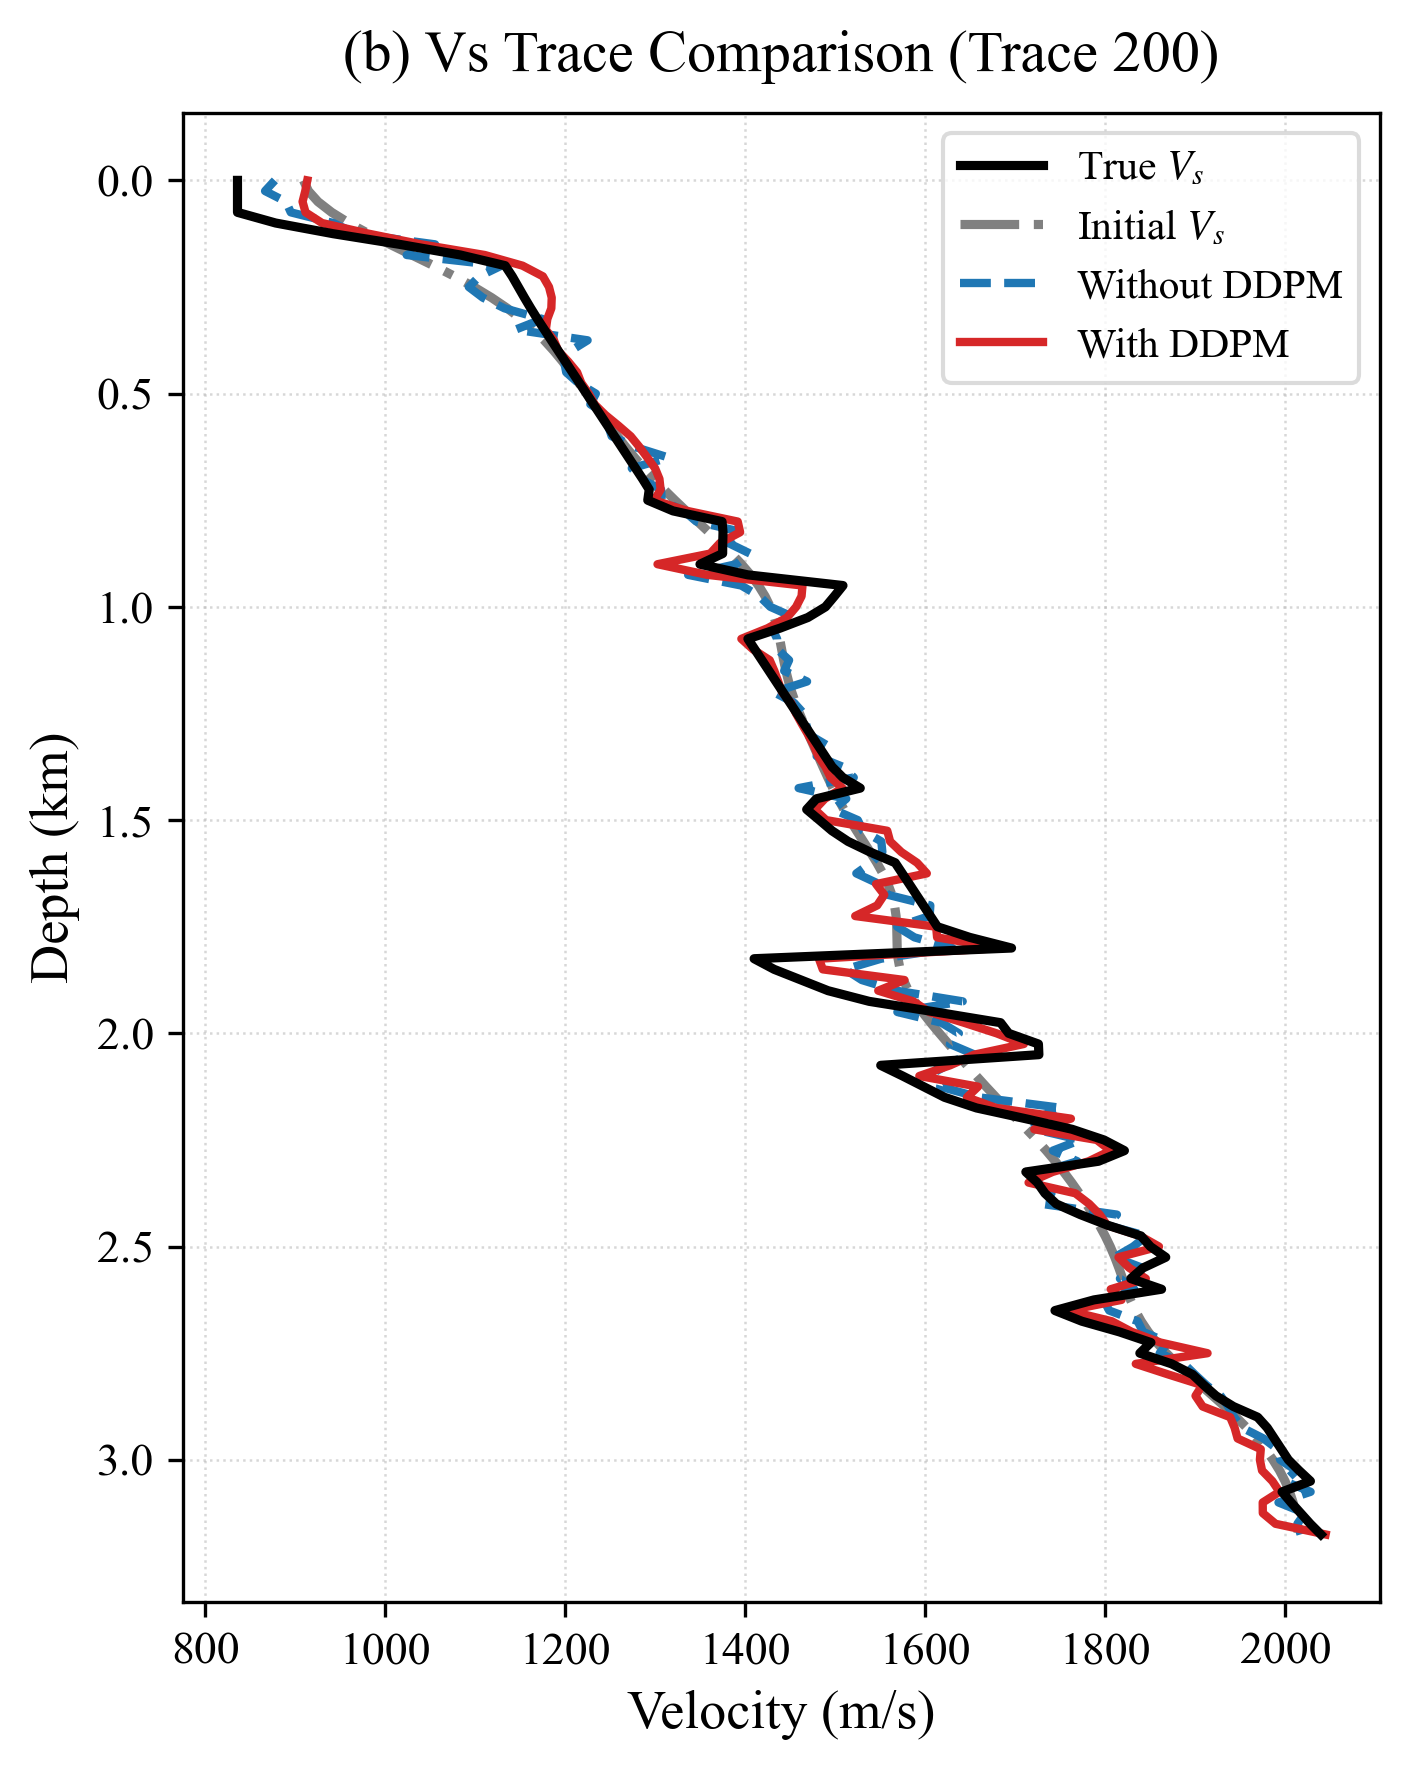

In [6]:
def plot_trace_four_vertical(
    vp_true,
    vp_initial,
    vp_with_ddpm,
    vp_without_ddpm,
    vs_true,
    vs_initial,
    vs_with_ddpm,
    vs_without_ddpm,
    num_trace=200,
    dz=25,
    save_dir=None,
    show=True,
):
    """Plot single-trace Vp and Vs comparisons for true, initial, no-DDPM, and DDPM models."""
    vp_true = to_2d(vp_true)
    vp_initial = to_2d(vp_initial)
    vp_with_ddpm = to_2d(vp_with_ddpm)
    vp_without_ddpm = to_2d(vp_without_ddpm)
    vs_true = to_2d(vs_true)
    vs_initial = to_2d(vs_initial)
    vs_with_ddpm = to_2d(vs_with_ddpm)
    vs_without_ddpm = to_2d(vs_without_ddpm)

    if num_trace < 0 or num_trace >= vp_true.shape[1]:
        raise ValueError(f"num_trace must be between 0 and {vp_true.shape[1] - 1}, got {num_trace}.")

    depth = np.arange(vp_true.shape[0]) * dz / 1000.0
    save_dir = Path(save_dir) if save_dir is not None else None

    fig, ax = plt.subplots(figsize=(4.8, 6), dpi=300)
    ax.plot(vp_true[:, num_trace], depth, label=r"True $V_p$", color="black", linewidth=2.2, zorder=10)
    ax.plot(vp_initial[:, num_trace], depth, label=r"Initial $V_p$", color="gray", linestyle="-.", linewidth=1.8)
    ax.plot(vp_without_ddpm[:, num_trace], depth, label="Without DDPM", color="#1f77b4", linestyle="--", linewidth=2.0)
    ax.plot(vp_with_ddpm[:, num_trace], depth, label="With DDPM", color="#d62728", linewidth=2.0)
    ax.invert_yaxis()
    ax.set_xlabel("Velocity (m/s)", fontsize=13)
    ax.set_ylabel("Depth (km)", fontsize=13)
    ax.set_title(f"(a) Vp Trace Comparison (Trace {num_trace})", fontsize=14, pad=10)
    ax.grid(True, linestyle=":", linewidth=0.6, alpha=0.5)
    ax.legend(fontsize=10, frameon=True, facecolor="white", edgecolor="lightgray")
    ax.tick_params(labelsize=11)
    plt.tight_layout()
    vp_save = save_dir / f"trace_{num_trace}_vp_comparison.png" if save_dir is not None else None
    save_or_show(fig, vp_save, show)

    fig, ax = plt.subplots(figsize=(4.8, 6), dpi=300)
    ax.plot(vs_true[:, num_trace], depth, label=r"True $V_s$", color="black", linewidth=2.2, zorder=10)
    ax.plot(vs_initial[:, num_trace], depth, label=r"Initial $V_s$", color="gray", linestyle="-.", linewidth=2.2)
    ax.plot(vs_without_ddpm[:, num_trace], depth, label="Without DDPM", color="#1f77b4", linestyle="--", linewidth=2.0)
    ax.plot(vs_with_ddpm[:, num_trace], depth, label="With DDPM", color="#d62728", linewidth=2.0)
    ax.invert_yaxis()
    ax.set_xlabel("Velocity (m/s)", fontsize=13)
    ax.set_ylabel("Depth (km)", fontsize=13)
    ax.set_title(f"(b) Vs Trace Comparison (Trace {num_trace})", fontsize=14, pad=10)
    ax.grid(True, linestyle=":", linewidth=0.6, alpha=0.5)
    ax.legend(fontsize=10, frameon=True, facecolor="white", edgecolor="lightgray")
    ax.tick_params(labelsize=11)
    plt.tight_layout()
    vs_save = save_dir / f"trace_{num_trace}_vs_comparison.png" if save_dir is not None else None
    save_or_show(fig, vs_save, show)


if not FORWARD_ONLY:
    result_with_ddpm, result_without_ddpm = require_inversion_results(result_with_ddpm, result_without_ddpm)
    plot_trace_four_vertical(
        vp_true=result_with_ddpm["vp_true"],
        vp_initial=result_with_ddpm["vp_init0"],
        vp_with_ddpm=result_with_ddpm["vp_after_ddpm"],
        vp_without_ddpm=result_without_ddpm["vp_final"],
        vs_true=result_with_ddpm["vs_true"],
        vs_initial=result_with_ddpm["vs_init0"],
        vs_with_ddpm=result_with_ddpm["vs_after_ddpm"],
        vs_without_ddpm=result_without_ddpm["vs_final"],
        num_trace=200,
        dz=25,
        save_dir=RESULT_DIR,
        show=SHOW_FIGURES,
    )
